In [2]:
from tensorflow.keras.datasets import cifar10
import matplotlib.pyplot as plt

(train_X, train_Y), (test_X, test_Y) = cifar10.load_data()

I0000 00:00:1791289883.610507   23163 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


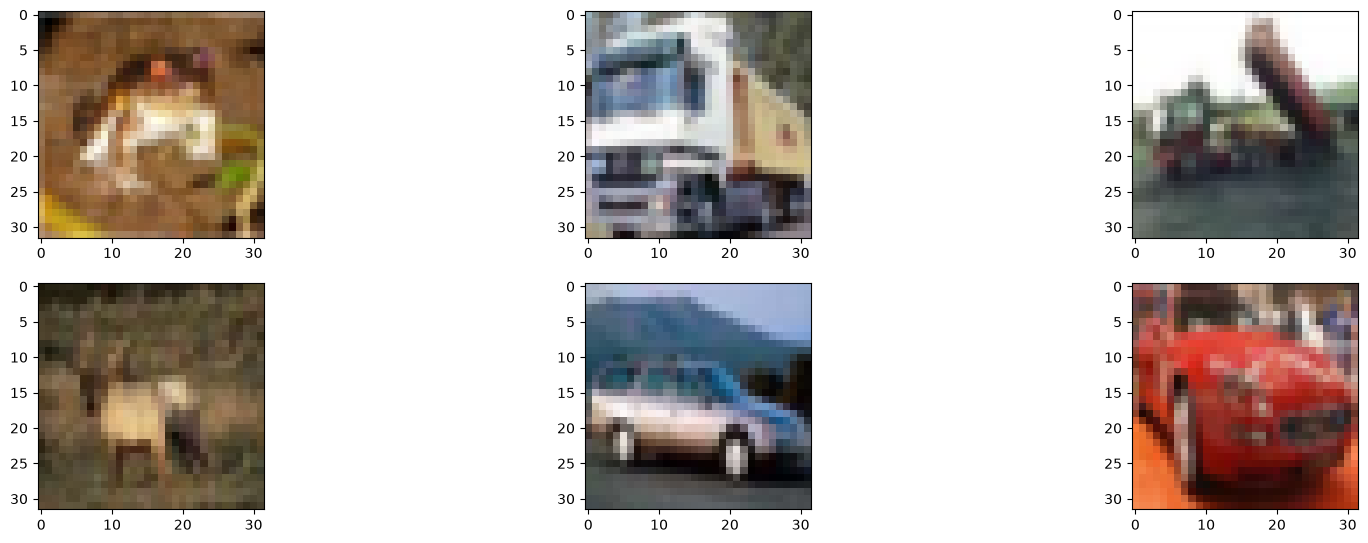

In [3]:
n = 6
plt.figure(figsize=(20, 10))
for i in range(n):
    plt.subplot(330 + 1 + i)
    plt.imshow(train_X[i])
plt.show()

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.constraints import MaxNorm

In [7]:
train_X = train_X.astype('float32') / 255.0
test_X = test_X.astype('float32') / 255.0
train_Y = to_categorical(train_Y)
test_Y = to_categorical(test_Y)

num_classes = test_Y.shape[1]

In [8]:
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', kernel_constraint=MaxNorm(3), padding='same', input_shape=(32, 32, 3)))
model.add(Dropout(0.2))
model.add(Conv2D(32, (3, 3), activation='relu', kernel_constraint=MaxNorm(3), padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(512, activation='relu', kernel_constraint=MaxNorm(3)))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))

/home/ubuntu24/PROJECTS/Image-Classification-Project/venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1791290379.263567   23163 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [9]:
sgd = SGD(learning_rate=0.01, momentum=0.9, nesterov=False, decay=0.01 / 25)
model.compile(loss='categorical_crossentropy', optimizer=sgd, metrics=['accuracy'])

/home/ubuntu24/PROJECTS/Image-Classification-Project/venv/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,210,090 (16.06 MB)

 Trainable params: 4,210,090 (16.06 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.fit(train_X, train_Y, validation_data=(test_X, test_Y), epochs=10, batch_size=32)

W0000 00:00:1791290516.761892   23163 cpu_allocator_impl.cc:82] Allocation of 614400000 exceeds 10% of free system memory.


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.3539 - loss: 1.7734

W0000 00:00:1791290726.238635   23163 cpu_allocator_impl.cc:82] Allocation of 122880000 exceeds 10% of free system memory.


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 214s 135ms/step - accuracy: 0.3539 - loss: 1.7734 - val_accuracy: 0.4761 - val_loss: 1.4702
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 214s 137ms/step - accuracy: 0.4755 - loss: 1.4531 - val_accuracy: 0.5276 - val_loss: 1.3285
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 184s 118ms/step - accuracy: 0.5411 - loss: 1.2842 - val_accuracy: 0.5780 - val_loss: 1.1759
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 187s 120ms/step - accuracy: 0.5919 - loss: 1.1524 - val_accuracy: 0.5958 - val_loss: 1.1372
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 203s 130ms/step - accuracy: 0.6323 - loss: 1.0357 - val_accuracy: 0.6198 - val_loss: 1.0786
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 203s 130ms/step - accuracy: 0.6695 - loss: 0.9384 - val_accuracy: 0.6396 - val_loss: 1.0277
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 223s 142ms/step - accuracy: 0.7017 - loss: 0.8424 - val_accuracy: 0.6577 - val_loss: 0.9904
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 204s 130ms/step - accuracy: 0.7

In [12]:
acc = model.evaluate(test_X, test_Y)
print(acc * 100)

W0000 00:00:1791292575.357856   23163 cpu_allocator_impl.cc:82] Allocation of 122880000 exceeds 10% of free system memory.


313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.6573 - loss: 1.0606
[1.06060791015625, 0.6572999954223633, 1.06060791015625, 0.6572999954223633, 1.06060791015625, 0.6572999954223633, 1.06060791015625, 0.6572999954223633, 1.06060791015625, 0.6572999954223633, 1.06060791015625, 0.6572999954223633, 1.06060791015625, 0.6572999954223633, 1.06060791015625, 0.6572999954223633, 1.06060791015625, 0.6572999954223633, 1.06060791015625, 0.6572999954223633, 1.06060791015625, 0.6572999954223633, 1.06060791015625, 0.6572999954223633, 1.06060791015625, 0.6572999954223633, 1.06060791015625, 0.6572999954223633, 1.06060791015625, 0.6572999954223633, 1.06060791015625, 0.6572999954223633, 1.06060791015625, 0.6572999954223633, 1.06060791015625, 0.6572999954223633, 1.06060791015625, 0.6572999954223633, 1.06060791015625, 0.6572999954223633, 1.06060791015625, 0.6572999954223633, 1.06060791015625, 0.6572999954223633, 1.06060791015625, 0.6572999954223633, 1.06060791015625, 0.6572999954223633, 1.060607910

In [13]:
model.save("model_cifar_10epoch.h5")

In [14]:
results = {0: "aeroplane", 1: "automobile", 2: "bird", 3: "cat", 4: "deer", 5: "dog", 6: "frog", 7: "horse", 8: "ship", 9: "truck"}

In [16]:
from PIL import Image
import numpy as np
im = Image.open("test_image.jpg").convert("RGB")
im = im.resize((32, 32))
im = np.array(im, dtype="float32") / 255.0  
im = np.expand_dims(im, axis=0)
pred = np.argmax(model.predict(im), axis=1)[0]
print(pred, results[pred])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 839ms/step
4 deer
